# GES Causal Discovery Demo

| Overview row | Method | Teaching point |
|---|---|---|
| Score-based | GES | A global score can prefer a coherent sparse DAG in small noisy window-summary data. |

Physical story: campaign and weather drive demand; demand and service outages drive support tickets. The sample is intentionally small and noisy, which makes a PC baseline conservative and less decisive.

In [ ]:
!pip3 install -q git+https://github.com/NetManAIOps/sktime.git causal-learn matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

from sktime.causal_discovery import GES, PC

In [2]:
rng = np.random.default_rng(0)
n = 80

campaign = rng.normal(size=n)
weather = rng.normal(size=n)
outage = rng.normal(size=n)
demand = 0.80 * campaign + 0.60 * weather + rng.normal(scale=0.90, size=n)
tickets = 0.80 * demand + 0.40 * outage + rng.normal(scale=0.90, size=n)

X = pd.DataFrame(
    {
        "Campaign": campaign,
        "Weather": weather,
        "Demand": demand,
        "Outage": outage,
        "Tickets": tickets,
    }
)
X = (X - X.mean()) / X.std()

TRUE_EDGES = {
    ("Campaign", "Demand"),
    ("Weather", "Demand"),
    ("Demand", "Tickets"),
    ("Outage", "Tickets"),
}
NODES = ["Campaign", "Weather", "Demand", "Outage", "Tickets"]
POSITIONS = {
    "Campaign": (0, 1.2),
    "Weather": (0, -0.2),
    "Demand": (1.45, 0.5),
    "Outage": (1.45, -1.0),
    "Tickets": (2.9, -0.25),
}

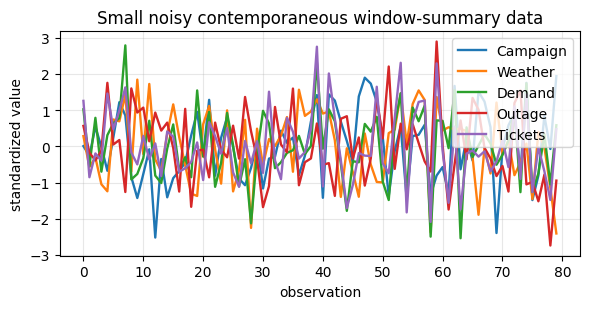

In [4]:
ax = X.plot(figsize=(6, 3.2), linewidth=1.7)
ax.set_title("Small noisy contemporaneous window-summary data")
ax.set_xlabel("observation")
ax.set_ylabel("standardized value")
ax.grid(alpha=0.3)
plt.tight_layout()

In [5]:
X.corr().round(2)

,Campaign,Weather,Demand,Outage,Tickets
Campaign,1.00,-0.07,0.56,-0.16,0.42
Weather,-0.07,1.00,0.42,-0.02,0.37
Demand,0.56,0.42,1.00,-0.14,0.75
Outage,-0.16,-0.02,-0.14,1.00,0.21
Tickets,0.42,0.37,0.75,0.21,1.00


In [7]:
COLORS = {
    "correct": "#2ca02c",
    "false positive": "#d62728",
    "missed": "#8c8c8c",
    "ambiguous": "#ff7f0e",
}


def status_for_edge(source, target, kind, true_edges):
    if kind == "directed" and (source, target) in true_edges:
        return "correct"
    if kind == "undirected" and ((source, target) in true_edges or (target, source) in true_edges):
        return "ambiguous"
    if (target, source) in true_edges:
        return "ambiguous"
    return "false positive"


def covered_true_edges(pred_edges, true_edges):
    covered = set()
    for source, target, kind in pred_edges:
        if (source, target) in true_edges:
            covered.add((source, target))
        if kind == "undirected" and (target, source) in true_edges:
            covered.add((target, source))
    return covered


def edge_table(pred_edges, true_edges):
    rows = []
    for source, target, kind in pred_edges:
        rows.append(
            {
                "source": source,
                "target": target,
                "type": kind,
                "status": status_for_edge(source, target, kind, true_edges),
            }
        )
    for source, target in sorted(true_edges - covered_true_edges(pred_edges, true_edges)):
        rows.append(
            {"source": source, "target": target, "type": "true edge", "status": "missed"}
        )
    return pd.DataFrame(rows)


def cpdag_edge_list(adjacency, names):
    edges = []
    for i, source in enumerate(names):
        for j, target in enumerate(names):
            if adjacency[i, j] == 1:
                edges.append((source, target, "directed"))
    for i, source in enumerate(names):
        for j, target in enumerate(names):
            if i < j and adjacency[i, j] == -1 and adjacency[j, i] == -1:
                edges.append((source, target, "undirected"))
    return edges


def score_edges(pred_edges, true_edges):
    table = edge_table(pred_edges, true_edges)
    return table["status"].value_counts().reindex(
        ["correct", "ambiguous", "false positive", "missed"], fill_value=0
    )


def draw_edge(ax, source, target, color, positions, node_artists, kind="directed", linestyle="-", rad=0.03):
    arrowstyle = "-|>" if kind == "directed" else "<|-|>"
    patch = FancyArrowPatch(
        positions[source],
        positions[target],
        arrowstyle=arrowstyle,
        mutation_scale=16,
        linewidth=2.5,
        color=color,
        linestyle=linestyle,
        connectionstyle=f"arc3,rad={rad}",
        patchA=node_artists[source].get_bbox_patch(),
        patchB=node_artists[target].get_bbox_patch(),
        shrinkA=7,
        shrinkB=7,
        zorder=2,
    )
    ax.add_patch(patch)


def draw_causal_graph(ax, nodes, positions, pred_edges, true_edges, title):
    node_artists = {}
    for node in nodes:
        x, y = positions[node]
        node_artists[node] = ax.text(
            x,
            y,
            node,
            ha="center",
            va="center",
            fontsize=10.5,
            zorder=3,
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "black", "lw": 1.2},
        )
    ax.figure.canvas.draw()

    for source, target in true_edges - covered_true_edges(pred_edges, true_edges):
        draw_edge(ax, source, target, COLORS["missed"], positions, node_artists, linestyle="--", rad=-0.06)

    for source, target, kind in pred_edges:
        status = status_for_edge(source, target, kind, true_edges)
        draw_edge(ax, source, target, COLORS[status], positions, node_artists, kind=kind)

    xs = [p[0] for p in positions.values()]
    ys = [p[1] for p in positions.values()]
    ax.set_xlim(min(xs) - 0.55, max(xs) + 0.55)
    ax.set_ylim(min(ys) - 0.65, max(ys) + 0.65)
    ax.set_title(title)
    ax.axis("off")


def plot_causal_graph(nodes, positions, pred_edges, true_edges, title):
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    draw_causal_graph(ax, nodes, positions, pred_edges, true_edges, title)
    add_graph_legend(fig)
    plt.tight_layout()


def plot_graph_comparison(nodes, positions, left_edges, right_edges, true_edges, left_title, right_title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    draw_causal_graph(axes[0], nodes, positions, left_edges, true_edges, left_title)
    draw_causal_graph(axes[1], nodes, positions, right_edges, true_edges, right_title)
    add_graph_legend(fig)
    plt.tight_layout()


def add_graph_legend(fig):
    legend = [
        Line2D([0], [0], color=COLORS["correct"], lw=3, label="correct directed edge"),
        Line2D([0], [0], color=COLORS["ambiguous"], lw=3, label="ambiguous orientation"),
        Line2D([0], [0], color=COLORS["false positive"], lw=3, label="false positive"),
        Line2D([0], [0], color=COLORS["missed"], lw=3, ls="--", label="missed true edge"),
    ]
    fig.legend(handles=legend, loc="lower center", ncol=4, frameon=False)


In [8]:
ges = GES(score_func="local_score_BIC")
ges.fit(X)
ges_edges = cpdag_edge_list(ges.get_adjacency_matrix(), NODES)

pc = PC(alpha=0.01)
pc.fit(X)
pc_edges = cpdag_edge_list(pc.get_adjacency_matrix(), NODES)

pd.DataFrame({"GES": score_edges(ges_edges, TRUE_EDGES), "PC baseline": score_edges(pc_edges, TRUE_EDGES)})

/Users/moonshot/Project/sktime/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,GES,PC baseline
status,,
correct,4,0
ambiguous,0,2
false positive,0,0
missed,0,2


In [9]:
edge_table(ges_edges, TRUE_EDGES)

,source,target,type,status
0,Campaign,Demand,directed,correct
1,Weather,Demand,directed,correct
2,Demand,Tickets,directed,correct
3,Outage,Tickets,directed,correct


In [10]:
edge_table(pc_edges, TRUE_EDGES)

,source,target,type,status
0,Campaign,Demand,undirected,ambiguous
1,Demand,Tickets,undirected,ambiguous
2,Outage,Tickets,true edge,missed
3,Weather,Demand,true edge,missed


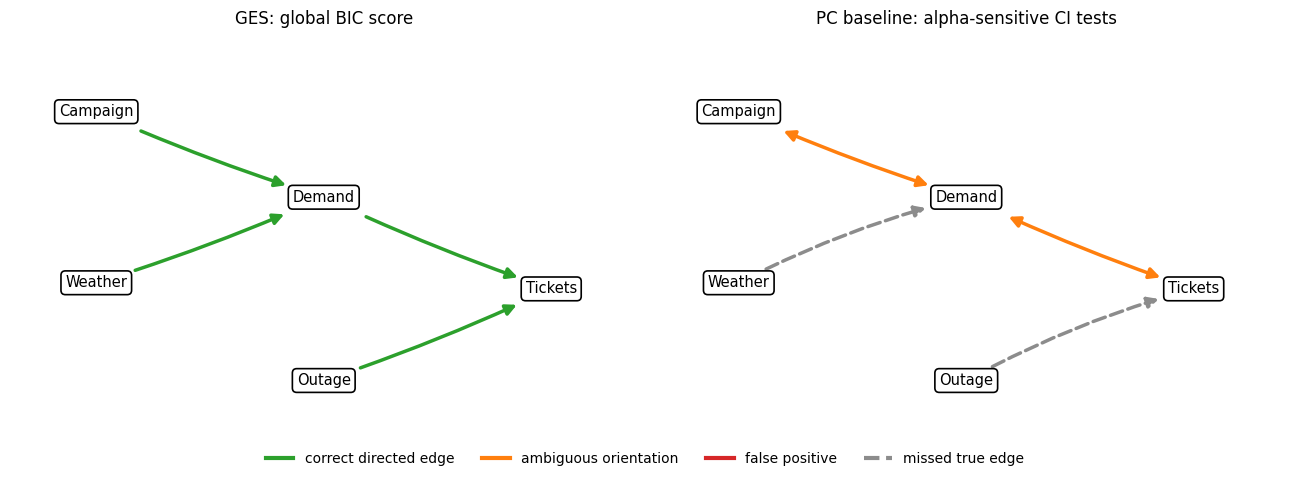

In [11]:
plot_graph_comparison(
    NODES,
    POSITIONS,
    ges_edges,
    pc_edges,
    TRUE_EDGES,
    "GES: global BIC score",
    "PC baseline: alpha-sensitive CI tests",
)

Takeaway: the point is not that GES is always better than PC. In this small noisy window-summary case, GES uses a global score to choose a complete sparse explanation, while PC's local independence tests leave weaker parts ambiguous or missing.